In [7]:
#step 1: importing lib
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import pandas as pd

train_df = pd.read_csv(
    r"C:\Users\GANAPATI\Downloads\archive\Genre Classification Dataset\train_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "Title", "Genre", "Description"]
)

df.head()


,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [14]:
# Keep only required columns (correct column names)
train_df = train_df[['Description', 'Genre']]

# Clean text column
train_df['Description'] = train_df['Description'].astype(str).str.strip()

# Remove empty descriptions
train_df = train_df[train_df['Description'] != ""]

# Drop missing values
train_df.dropna(inplace=True)

# Rename columns to standard ML-friendly names
train_df.rename(columns={
    'Description': 'description',
    'Genre': 'genre'
}, inplace=True)

# Shuffle data
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", train_df.shape)


Dataset shape: (54214, 2)


C:\Users\GANAPATI\AppData\Local\Temp\ipykernel_12044\3422359643.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Description'] = train_df['Description'].astype(str).str.strip()


In [15]:
X = train_df['description']
y = train_df['genre']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 43371
Testing samples: 10843


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 1)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [18]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=3000,
    n_jobs=-1
)

classifier.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [19]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = classifier.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.5805588859171816

Classification Report:

               precision    recall  f1-score   support

      action        0.60      0.24      0.35       263
       adult        0.68      0.22      0.33       118
   adventure        0.59      0.11      0.18       155
   animation        0.60      0.03      0.06       100
   biography        0.00      0.00      0.00        53
      comedy        0.54      0.61      0.57      1490
       crime        0.00      0.00      0.00       101
 documentary        0.65      0.87      0.75      2619
       drama        0.53      0.79      0.63      2723
      family        0.53      0.06      0.10       157
     fantasy        0.00      0.00      0.00        65
   game-show        0.91      0.51      0.66        39
     history        0.00      0.00      0.00        49
      horror        0.70      0.52      0.60       441
       music        0.62      0.36      0.46       146
     musical        0.00      0.00      0.00        55
     myste

C:\Users\GANAPATI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\GANAPATI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\GANAPATI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [20]:
sample_movie = [
    "A young hero rises against a corrupt system to save his family and city"
]

sample_vec = vectorizer.transform(sample_movie)
prediction = classifier.predict(sample_vec)

print("Predicted Genre:", prediction[0])


Predicted Genre:  action 


In [21]:
import pickle

with open("movie_genre_model.pkl", "wb") as f:
    pickle.dump(classifier, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)


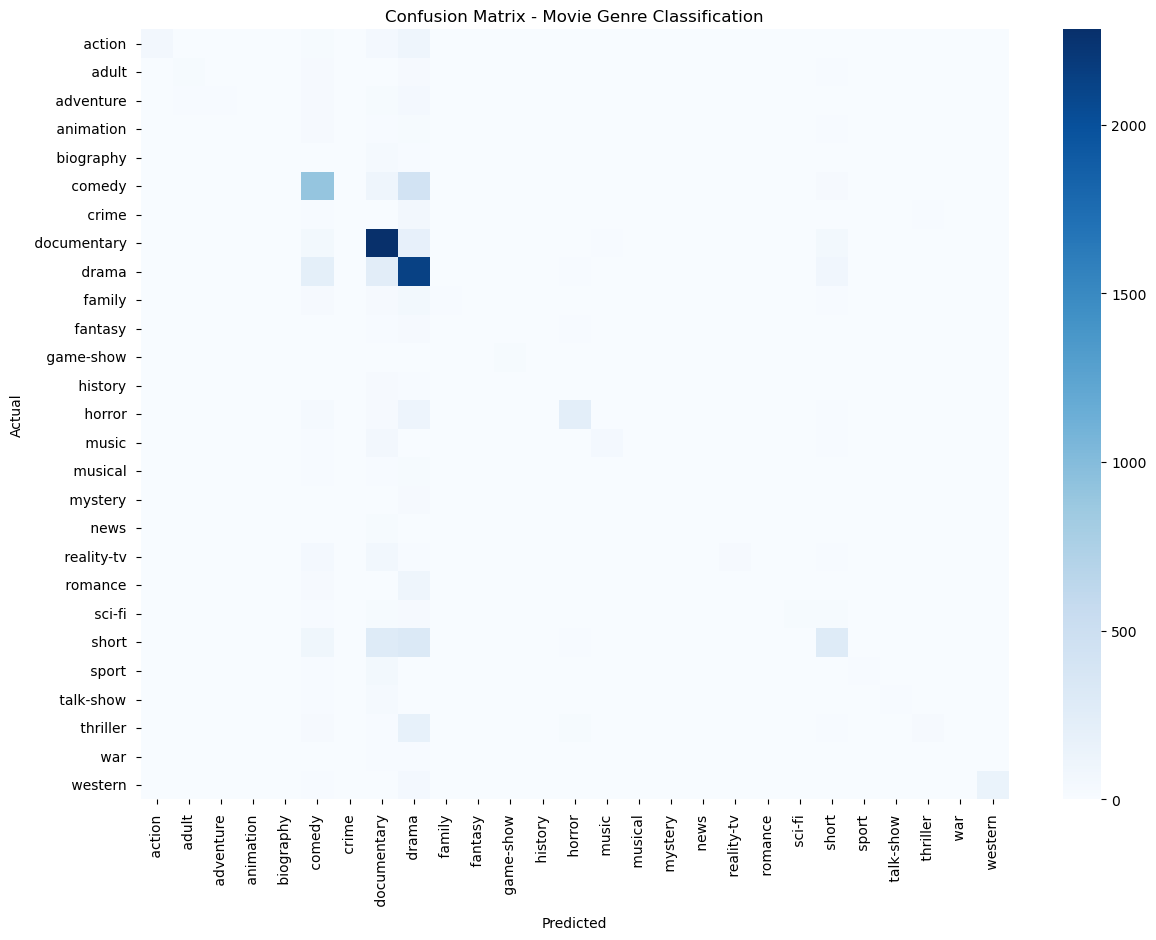

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classifier.classes_,
    yticklabels=classifier.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Movie Genre Classification")
plt.show()
